In [1]:
import pandas as pd
import numpy as np

C:\Users\jadha\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# LOADING ALL THE DATASETS 
Loan_Applications=pd.read_csv(r"C:\Users\jadha\Downloads\loans_master.csv")
Customer_Bureau=pd.read_csv(r"C:\Users\jadha\Downloads\customer_bureau.csv")
Payment_History=pd.read_csv(r"C:\Users\jadha\Downloads\payment_history.csv")
Loan_Performance=pd.read_csv(r"C:\Users\jadha\Downloads\loan_performance.csv")
EMI_Tracking=pd.read_csv(r"C:\Users\jadha\Downloads\monthly_emi_track.csv")
Collateral=pd.read_csv(r"C:\Users\jadha\Downloads\collateral_assets.csv")
Branch_Economy=pd.read_csv(r"C:\Users\jadha\Downloads\branch_region_economy.csv")
Credit_Cards=pd.read_csv(r"C:\Users\jadha\Downloads\credit_card_behavior.csv")
Enquiry_Bureau=pd.read_csv(r"C:\Users\jadha\Downloads\loan_enquiry_bureau.csv")



In [3]:
# MERGING THE ALL TABLES
df = Loan_Applications.merge(Customer_Bureau,on='loan_id',how='left',copy=False).merge(Payment_History,on='loan_id',how='left',copy=False).merge(Loan_Performance,on='loan_id',how='left',copy=False).merge(EMI_Tracking,on='loan_id',how='left',copy=False).merge(Collateral,on='loan_id',how='left',copy=False).merge(Branch_Economy,on='loan_id',how='left',copy=False).merge(Credit_Cards,on='loan_id',how='left',copy=False).merge(Enquiry_Bureau,on='loan_id',how='left',copy=False)

In [4]:
before = df.memory_usage(deep=True).sum() / 1024**2
print(f"Memory Before Downcasting: {before:.2f} MB")

Memory Before Downcasting: 7208.61 MB


In [5]:
for col in df.select_dtypes(include=['int']).columns:
    df[col] = pd.to_numeric(df[col], downcast='integer')

for col in df.select_dtypes(include=['float']).columns:
    df[col] = pd.to_numeric(df[col], downcast='float')

In [6]:
after = df.memory_usage(deep=True).sum() / 1024**2

print(f"Memory After Downcasting: {after:.2f} MB")
print(f"Saved: {before-after:.2f} MB")
print(f"Reduction: {((before-after)/before)*100:.2f}%")

Memory After Downcasting: 6092.81 MB
Saved: 1115.80 MB
Reduction: 15.48%


In [7]:
# SAVING IT AS A PARQUET FILE
df.to_parquet("finsight_merged.parquet",index=False)

In [8]:
# LOADING THAT PARQUET FILE
df = pd.read_parquet("finsight_merged.parquet")

In [9]:
after = df.memory_usage(deep=True).sum() / 1024**2
print(f"Memory After Downcasting: {before:.2f} MB")

Memory After Downcasting: 7208.61 MB


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Columns: 182 entries, loan_id to tat_within_sla_flag
dtypes: float32(55), float64(29), int16(3), int32(1), int8(49), object(45)
memory usage: 1.6+ GB


In [11]:
df.shape

(2000000, 182)

#### Orphan Records Description

Orphan records are records that exist in a child table but do not have a corresponding loan_id in the parent loan application table. Such records indicate referential integrity issues that may arise from incomplete ETL processes, data migration errors, or inconsistencies between source systems. Identifying orphan records is important because they can lead to inaccurate borrower profiles and unreliable analytical results.

In [12]:
tables = [
    ("Customer_Bureau", Customer_Bureau),
    ("Payment_History", Payment_History),
    ("Loan_Performance", Loan_Performance),
    ("EMI_Tracking", EMI_Tracking),
    ("Collateral", Collateral),
    ("Branch_Economy", Branch_Economy),
    ("Credit_Cards", Credit_Cards),
    ("Enquiry_Bureau", Enquiry_Bureau)
]

for name, table in tables:

    orphan_count = (
        ~table['loan_id'].isin(
            Loan_Applications['loan_id']
        )
    ).sum()

    print(
        f"{name} Orphan Records : "
        f"{orphan_count}"
    )

Customer_Bureau Orphan Records : 0
Payment_History Orphan Records : 0
Loan_Performance Orphan Records : 0
EMI_Tracking Orphan Records : 0
Collateral Orphan Records : 0
Branch_Economy Orphan Records : 0
Credit_Cards Orphan Records : 0
Enquiry_Bureau Orphan Records : 0


### Q1(c) Dirty Data Detection & Cleaning

Checks were conducted for negative interest rates, zero annual income, invalid debt-to-income ratios, and negative revolving credit utilization percentages. Instead of deleting these observations, a dirty_flag variable was created to preserve traceability while correcting the affected values using appropriate imputation techniques.

In [13]:
#Identify dirty records: int_rate_pct<0, annual_inc_inr==0, dti_pct>100, revol_util_pct<0. Create a dirty_flag binary column. Do NOT delete these rows — flag and impute.

df['dirty_flag'] = np.where(
    (df['int_rate_pct'] < 0) |
    (df['annual_inc_inr'] <= 0) |
    (df['dti_pct'] > 100) |
    (df['dti_pct'] < 0) |
    (df['revol_util_pct'] < 0) |
    (df['revol_util_pct'] > 100),
    1,
    0
)

In [14]:
print("Negative Interest:", (df['int_rate_pct'] < 0).sum())

print("Zero Income:", (df['annual_inc_inr'] == 0).sum())

print("DTI >100:",((df['dti_pct'] > 100) | ((df['dti_pct'] < 0))).sum())

print("Negative Revol Util:",((df['revol_util_pct'] < 0) | (df['revol_util_pct'] > 100)).sum())

Negative Interest: 0
Zero Income: 0
DTI >100: 0
Negative Revol Util: 0


### Cleaning

In [15]:
# Negative Interest Rate
df.loc[
    df['int_rate_pct'] < 0,
    'int_rate_pct'
] = np.nan

df['int_rate_pct'] = (
    df.groupby('grade')['int_rate_pct']
      .transform(
          lambda x: x.fillna(x.median())
      )
)

# Zero Income
df.loc[
    df['annual_inc_inr'] <= 0,
    'annual_inc_inr'
] = np.nan

df['annual_inc_inr'] = (
    df.groupby('emp_title')
      ['annual_inc_inr']
      .transform(
          lambda x: x.fillna(x.median())
      )
)

# Invalid DTI
df.loc[
    (df['dti_pct'] < 0) |
    (df['dti_pct'] > 100),
    'dti_pct'
] = np.nan

df['dti_pct'] = (
    df.groupby('grade')
      ['dti_pct']
      .transform(
          lambda x: x.fillna(x.median())
      )
)

# Negative Revolving Utilization
df['revol_util_pct'] = (
    df['revol_util_pct'].abs()
)

In [16]:
# CHECKING ALL THE NULL VALUES IN EACH COLUMN
null_dict={}
for i in df.columns:
    if (df[i].isna().sum())>0:
        null_dict[i]=df[i].isna().sum()

null_dict
    

{'emp_length_years': 180539,
 'revol_util_pct': 140097,
 'mort_acc': 260330,
 'pub_rec': 118951,
 'delinq_2yrs': 100207,
 'num_inq_last6m': 80130,
 'pct_tl_nvr_dlq': 59892,
 'bc_util_pct': 160397,
 'il_util_pct': 200167,
 'all_util_pct': 79649,
 'avg_cur_bal_inr': 100027,
 'mths_since_last_delinq': 1098640,
 'mths_since_last_record': 1598332,
 'last_pymnt_amnt_inr': 119889,
 'collection_recovery_fee': 120086,
 'cibil_score_band': 10,
 'avg_payment_delay_days': 120364,
 'emi_bank_name': 120236,
 'pdc_count': 120057,
 'collateral_type': 1258896,
 'ltv_ratio_pct': 1472196,
 'property_type': 1679672,
 'property_city_tier': 1679672,
 'vehicle_type': 1879789,
 'valuation_agency': 1370048,
 'charge_type': 1258896,
 'collateral_score': 298379,
 'loan_officer_exp_years': 139366,
 'branch_sanction_rate': 140557,
 'cash_advance_inr': 160223,
 'primary_card_type': 560528,
 'primary_cc_bank': 560528,
 'top_spend_category': 560528,
 'cc_payment_score': 160149,
 'income_doc_type': 308704,
 'field_ver

**Q1 D) Classify the missing-value pattern for each high-missing column
(mths_since_last_delinq, mort_acc, emp_length_years, il_util_pct) as MCAR,
MAR, or MNAR. Justify each classification using either Little&#39;s MCAR test output or
domain reasoning. Apply the correct imputation strategy and verify with
.isnull().sum() before and after.**



### Q1(d) Missing Value Analysis & Imputation

In [17]:
'''This step identifies the columns with the highest number of missing values.Understanding the extent of
missingness helps in selecting appropriate imputation techniques and prevents information loss during analysis.'''

missing_values = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_values.head(20)

vehicle_type              1879789
property_type             1679672
property_city_tier        1679672
mths_since_last_record    1598332
ltv_ratio_pct             1472196
valuation_agency          1370048
charge_type               1258896
collateral_type           1258896
mths_since_last_delinq    1098640
primary_card_type          560528
primary_cc_bank            560528
top_spend_category         560528
income_doc_type            308704
collateral_score           298379
mort_acc                   260330
il_util_pct                200167
emp_length_years           180539
bc_util_pct                160397
cash_advance_inr           160223
cc_payment_score           160149
dtype: int64

In [18]:
'''The variable mths_since_last_delinq contains 1,098,640 missing values. 
In credit-risk datasets, missing values generally indicate that the borrower has never experienced a delinquency event. 
Therefore, the missingness itself carries useful information and was treated as Missing Not At Random (MNAR).
A sentinel value of 999 was assigned to explicitly represent borrowers with no delinquency history.'''

df['mths_since_last_delinq'] = (
    df['mths_since_last_delinq']
      .fillna(999)
)


In [19]:
'''The mort_acc variable contains 260,330 missing values. Since mortgage accounts may genuinely be absent
for many borrowers, missing values were replaced with zero.This assumption is consistent with banking practice
where the absence of mortgage information often implies no mortgage accounts are held by the customer.'''

df['mort_acc'] = (
    df['mort_acc']
      .fillna(0)
)

In [20]:
'''The employment length variable contains 180,539 missing values. Employment duration is an important indicator
of job stability and repayment capacity. Missing values were imputed using the median employment length within 
the same job category, allowing occupational characteristics to be preserved while minimizing information loss.'''

df['emp_length_years'] = (
    df.groupby('emp_title')
      ['emp_length_years']
      .transform(
          lambda x: x.fillna(x.median())
      )
)

In [22]:
'''The variable il_util_pct contains 200,167 missing values. So filling data with group median'''


df['il_util_pct'] = (
    df.groupby('grade')['il_util_pct']
      .transform(lambda x: x.fillna(x.median()))
)

In [23]:
'''Missing bankcard utilization values were imputed using the median utilization of borrowers belonging to the 
same loan grade. This maintains risk-segment-specific utilization patterns.'''

df['bc_util_pct'] = (
    df.groupby('grade')['bc_util_pct']
      .transform(lambda x: x.fillna(x.median()))
)

In [24]:
'''The variables primary_card_type, primary_cc_bank, and top_spend_category each contain 560,528 missing values.
These missing values likely correspond to borrowers who do not possess a credit card. Therefore, a new category
labelled "No Card" was created to preserve this meaningful business information rather than treating it as random 
missingness'''

df['primary_card_type'] = (
    df['primary_card_type']
      .fillna('No Card')
)

df['primary_cc_bank'] = (
    df['primary_cc_bank']
      .fillna('No Card')
)

df['top_spend_category'] = (
    df['top_spend_category']
      .fillna('No Card')
)

In [25]:
'''The variable income_doc_type contains 308,704 missing values. Since document type is a categorical variable, mode
imputation was applied. This approach preserves the most frequently observed income verification method while ensuring
that no missing values remain.'''


df['income_doc_type'] = (
    df['income_doc_type']
      .fillna(
          df['income_doc_type'].mode()[0]
      )
)

In [26]:
'''A final validation was performed after all imputation steps to confirm that missing values were handled according to
their business context. This verification ensures that the dataset is suitable for exploratory data analysis, feature 
engineering, and predictive modelling without data-quality related interruptions.'''

df.isnull().sum().sort_values(
    ascending=False
).head(20)

vehicle_type               1879789
property_city_tier         1679672
property_type              1679672
mths_since_last_record     1598332
ltv_ratio_pct              1472196
valuation_agency           1370048
collateral_type            1258896
charge_type                1258896
collateral_score            298379
cash_advance_inr            160223
cc_payment_score            160149
branch_sanction_rate        140557
revol_util_pct              140097
loan_officer_exp_years      139366
avg_payment_delay_days      120364
emi_bank_name               120236
collection_recovery_fee     120086
pdc_count                   120057
processing_days             119899
last_pymnt_amnt_inr         119889
dtype: int64

**(e) Apply winsorisation at the 1st and 99th percentile to the six most skewed numeric
columns. Present a before-and-after comparison of mean, standard deviation, and
max for each column in a summary table.**

In [29]:
# Step 1: Identify Six Most Skewed Numeric Columns

numeric_cols = df.select_dtypes(
    include=['int8','int16','int32',
             'float32','float64']
).columns

# Remove binary flags
exclude_cols = [
    'loan_status',
    'npa_flag',
    'dirty_flag',
    'has_collateral',
    'loan_secured_flag',
    'prepayment_flag',
    'insurance_flag'
]

numeric_cols = [
    col for col in numeric_cols
    if col not in exclude_cols
]

skew_df = pd.DataFrame({
    'Column': numeric_cols,
    'Skewness': df[numeric_cols].skew()
})

skew_df['Abs_Skewness'] = (
    skew_df['Skewness'].abs()
)

skew_df = skew_df.sort_values(
    by='Abs_Skewness',
    ascending=False
)

top6_skewed = (
    skew_df.head(6)['Column']
    .tolist()
)

print(top6_skewed)

['collections_12mths_fee', 'collection_recovery_fee', 'recoveries_inr', 'emi_advance_paid_inr', 'expected_loss_inr', 'avg_cur_bal_inr']


In [30]:
'''The six most skewed continuous variables were selected based on skewness analysis. Summary statistics including mean,
standard deviation, and maximum value were calculated before winsorization to establish a baseline for comparison.'''



top6_skewed = [
    'collections_12mths_fee',
    'collection_recovery_fee',
    'recoveries_inr',
    'emi_advance_paid_inr',
    'expected_loss_inr',
    'avg_cur_bal_inr'
]

before_stats = (
    df[top6_skewed]
    .agg(['mean', 'std', 'max'])
    .T
)

before_stats

,mean,std,max
collections_12mths_fee,32.366464,560.070667,312618.52
collection_recovery_fee,130.709817,2061.435988,1035421.73
recoveries_inr,52.749164,818.402452,313742.97
emi_advance_paid_inr,2204.312963,13599.895685,5329334.00
expected_loss_inr,139.237678,1285.912722,189646.84
avg_cur_bal_inr,3738.269933,12551.713832,2434032.72


In [31]:
'''Winsorization was applied at the 1st and 99th percentiles. Values below the lower threshold were replaced with the
1st percentile value, while values above the upper threshold were capped at the 99th percentile value. This approach 
reduces the influence of extreme observations without removing any records.'''

for col in top6_skewed:

    lower = df[col].quantile(0.01)

    upper = df[col].quantile(0.99)

    df[col] = np.clip(
        df[col],
        lower,
        upper
    )

In [32]:
'''Summary statistics were recalculated after winsorization to evaluate changes in the distribution of the selected 
variables. A decrease in standard deviation and maximum values indicates successful outlier treatment.'''

after_stats = (
    df[top6_skewed]
    .agg(['mean', 'std', 'max'])
    .T
)

after_stats

,mean,std,max
collections_12mths_fee,11.829477,77.296128,657.2202
collection_recovery_fee,55.189725,348.528316,2911.0688
recoveries_inr,22.139089,140.021787,1172.0600
emi_advance_paid_inr,1708.033934,5752.164359,40329.1235
expected_loss_inr,84.350827,500.602668,3990.4218
avg_cur_bal_inr,3284.088494,6610.049151,44733.4364


In [33]:
'''The comparison table presents the mean, standard deviation, and maximum values before and after winsorization 
for each selected variable. This allows direct assessment of the impact of outlier treatment on the distribution of 
the data.'''

comparison = pd.concat(
    [before_stats, after_stats],
    axis=1,
    keys=[
        'Before Winsorization',
        'After Winsorization'
    ]
)

comparison

Before Winsorization                            \
                                        mean           std         max   
collections_12mths_fee             32.366464    560.070667   312618.52   
collection_recovery_fee           130.709817   2061.435988  1035421.73   
recoveries_inr                     52.749164    818.402452   313742.97   
emi_advance_paid_inr             2204.312963  13599.895685  5329334.00   
expected_loss_inr                 139.237678   1285.912722   189646.84   
avg_cur_bal_inr                  3738.269933  12551.713832  2434032.72   

                        After Winsorization                           
                                       mean          std         max  
collections_12mths_fee            11.829477    77.296128    657.2202  
collection_recovery_fee           55.189725   348.528316   2911.0688  
recoveries_inr                    22.139089   140.021787   1172.0600  
emi_advance_paid_inr            1708.033934  5752.164359  40329.1235  
expected_loss_inr                 84.350827   500.602668   3990.4218  
avg_cur_bal_inr                 3284.088494  6610.049151  44733.4364

#### Description

The six most skewed numeric variables were identified using skewness analysis and subjected to winsorization at the 1st and 99th percentile levels. This technique caps extreme values while retaining all observations, thereby reducing the influence of outliers on statistical analysis and predictive modelling.

#### Interpretation

The comparison table shows a substantial reduction in the maximum values and standard deviations of all six variables after winsorization. For example, the maximum value of collection_recovery_fee decreased from 1,035,421.73 to 2,911.07, while its standard deviation reduced from 2061.44 to 348.53. Similarly, emi_advance_paid_inr exhibited a significant decline in maximum value from 5,329,334.00 to 40,329.12, indicating the presence of extreme observations that were successfully controlled.

Across all selected variables, the mean values decreased moderately while the standard deviations reduced substantially. This suggests that a small number of extreme records were disproportionately influencing the distributions. Winsorization effectively limited the impact of these outliers without deleting any observations, resulting in more stable distributions suitable for exploratory analysis, statistical modelling, and credit-risk prediction.

#### Conclusion

Winsorization successfully reduced the influence of extreme observations in the six most skewed variables. The dataset now exhibits lower variability and more representative summary statistics while preserving all 2 million records. This improves the reliability and robustness of downstream machine learning and risk analytics models.

### QUESTION 2 EXPLORATORY DATA ANALYSIS

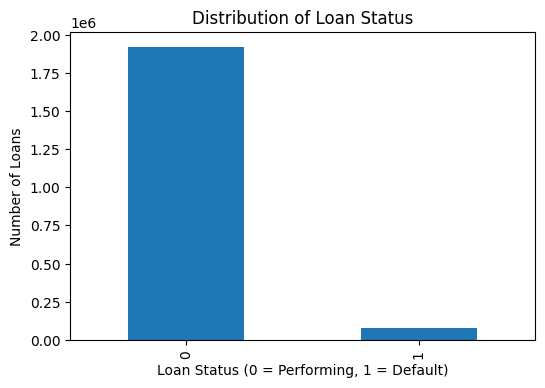

In [37]:
'''Q2(a) Distribution of Loan Status
Bar Chart'''

import matplotlib.pyplot as plt

loan_counts = df['loan_status'].value_counts()

plt.figure(figsize=(6,4))

loan_counts.plot(kind='bar')

plt.title("Distribution of Loan Status")
plt.xlabel("Loan Status (0 = Performing, 1 = Default)")
plt.ylabel("Number of Loans")

plt.show()

Description

The bar chart shows the distribution of performing and defaulted loans in the portfolio. It provides a clear view of class proportions and helps identify potential class imbalance issues that may affect predictive modelling 

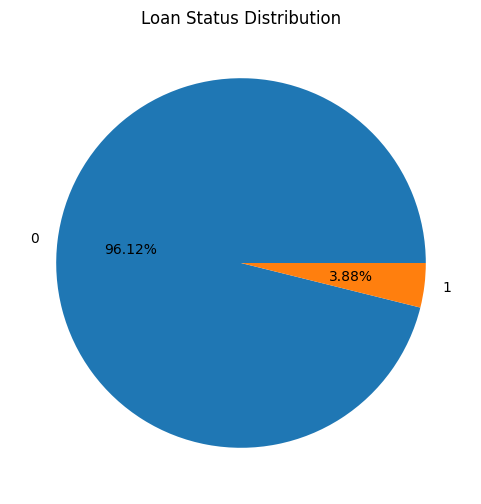

In [39]:
plt.figure(figsize=(6,6))

df['loan_status'].value_counts().plot(
    kind='pie',
    autopct='%1.2f%%'
)

plt.title('Loan Status Distribution')
plt.ylabel('')

plt.show()

Description

A pie chart was generated to illustrate the percentage contribution of performing and defaulted loans. This visualization provides a clear representation of the portfolio composition.

In [44]:
# Exact Default Rate & Class Imbalance
default_rate = (
    df['loan_status']
      .mean() * 100
)

performing_rate = (
    100 - default_rate
)

imbalance_ratio = (
    df['loan_status'].value_counts()[0]
    /
    df['loan_status'].value_counts()[1]
)

print("Default Rate :", round(default_rate,2),"%")
print("Performing Rate :", round(performing_rate,2),"%")
print("Imbalance Ratio :", round(imbalance_ratio,2),":1")

Default Rate : 3.88 %
Performing Rate : 96.12 %
Imbalance Ratio : 24.79 :1


C:\Users\jadha\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\jadha\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


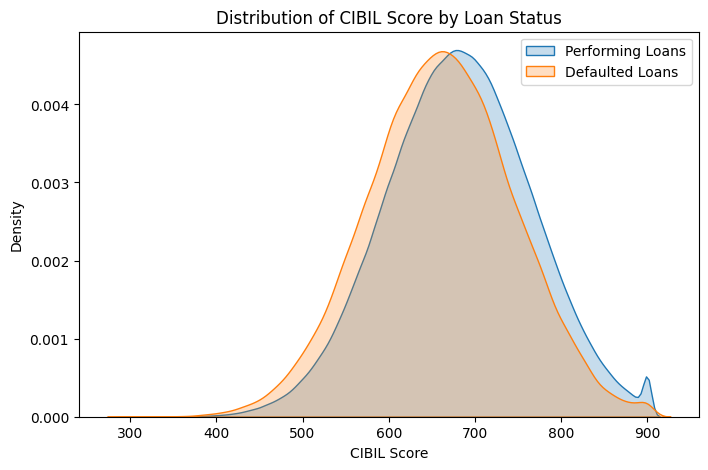

In [45]:
#Q2(b) CIBIL Score KDE

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df[df['loan_status']==0],
    x='cibil_score',
    fill=True,
    label='Performing Loans'
)

sns.kdeplot(
    data=df[df['loan_status']==1],
    x='cibil_score',
    fill=True,
    label='Defaulted Loans'
)

plt.title('Distribution of CIBIL Score by Loan Status')
plt.xlabel('CIBIL Score')
plt.ylabel('Density')
plt.legend()

plt.show()

In [46]:
x1 = df[df['loan_status']==0]['cibil_score']
x2 = df[df['loan_status']==1]['cibil_score']

print("Performing Mean:",x1.mean())
print("Default Mean:",x2.mean())

Performing Mean: 680.6806299689354
Default Mean: 660.1060910825726


In [48]:
pooled_std = np.sqrt(
((len(x1)-1)*x1.std()**2 +
(len(x2)-1)*x2.std()**2)
/
(len(x1)+len(x2)-2)
)

cohens_d = (
x1.mean()-x2.mean()
)/pooled_std

print(cohens_d)

0.24338948467338994


The KDE curves compare the distribution of CIBIL scores between performing and defaulted borrowers. A higher mean CIBIL score among performing borrowers would indicate better creditworthiness. Any substantial overlap between the two distributions suggests that CIBIL score alone is insufficient for accurate default prediction and should be combined with additional behavioural and financial variables.

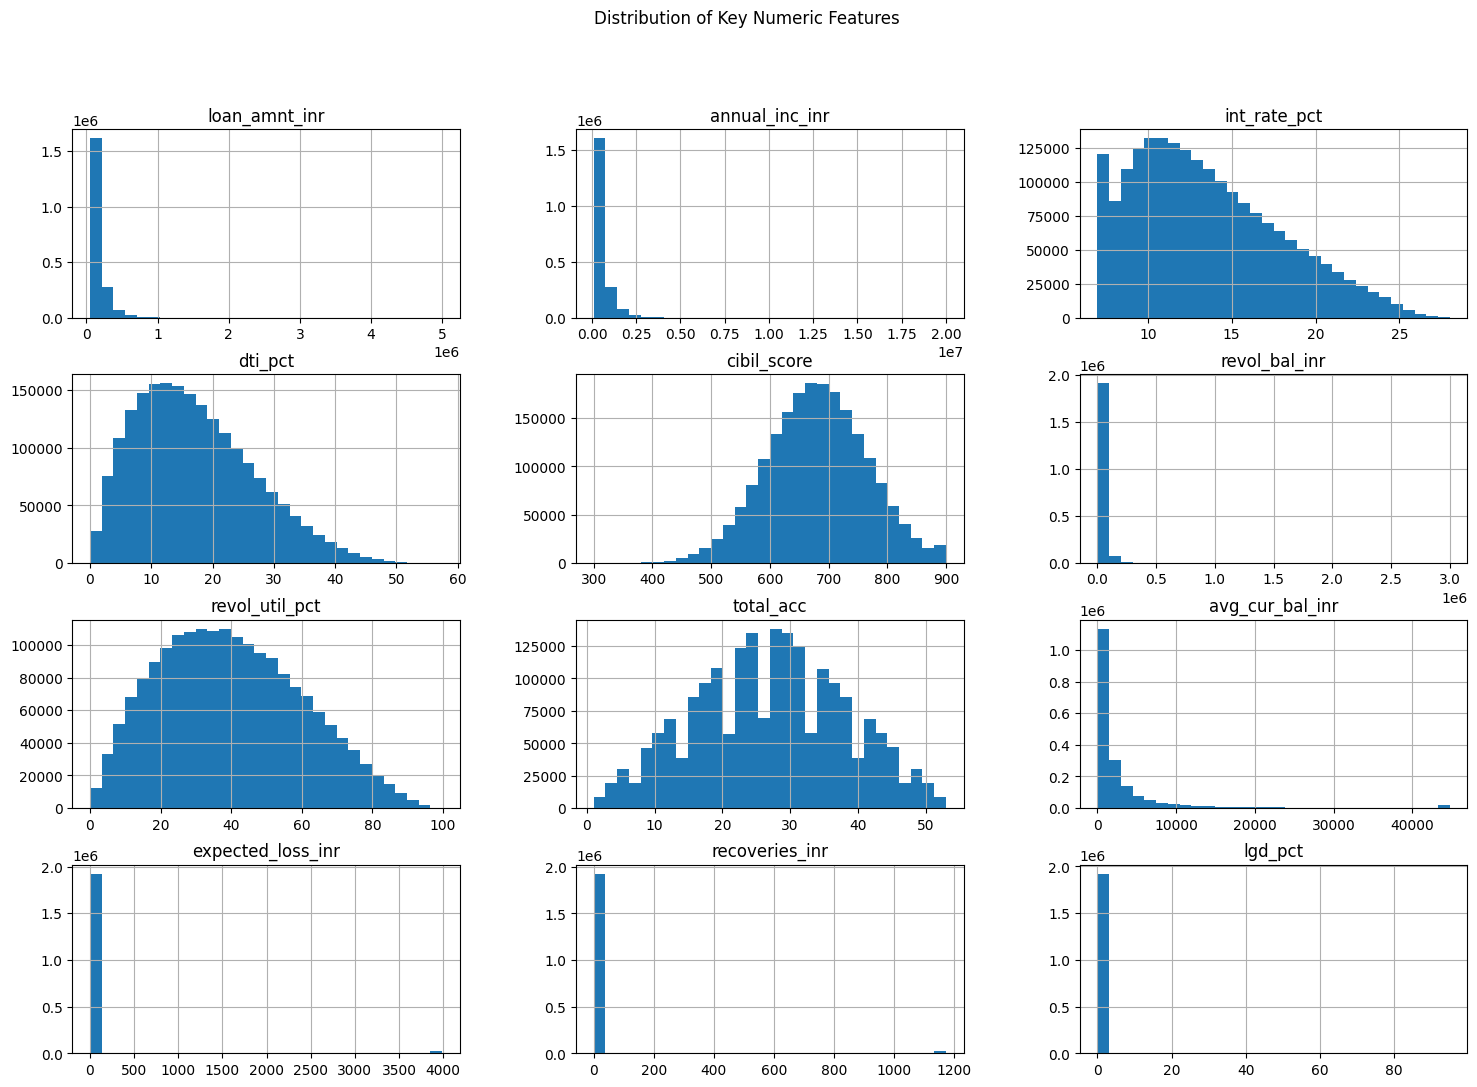

In [49]:
#Q2(c) Histogram Grid

num_cols = [
'loan_amnt_inr',
'annual_inc_inr',
'int_rate_pct',
'dti_pct',
'cibil_score',
'revol_bal_inr',
'revol_util_pct',
'total_acc',
'avg_cur_bal_inr',
'expected_loss_inr',
'recoveries_inr',
'lgd_pct'
]

df[num_cols].hist(
figsize=(18,12),
bins=30
)

plt.suptitle(
'Distribution of Key Numeric Features'
)

plt.show()

In [50]:
df[num_cols].skew().sort_values(
ascending=False
)

revol_bal_inr        9.610805
recoveries_inr       7.164084
expected_loss_inr    6.649011
lgd_pct              6.254093
annual_inc_inr       4.728191
avg_cur_bal_inr      4.212462
loan_amnt_inr        3.651117
dti_pct              0.597136
int_rate_pct         0.590027
revol_util_pct       0.287196
total_acc            0.000877
cibil_score         -0.034678
dtype: float64

In [77]:
skewed_cols = [
'expected_loss_inr',
'recoveries_inr',
'avg_cur_bal_inr',
'revol_bal_inr',
'lgd_pct',
'loan_amnt_inr']

for col in skewed_cols:

    df[f'log_{col}'] = np.log1p(
        df[col]
    )

In [78]:
for col in skewed_cols:

    print(
        col,
        df[col].skew(),
        df[f'log_{col}'].skew()
    )

expected_loss_inr 6.649010638783109 4.884884996028019
recoveries_inr 7.164084235529741 5.040592578982997
avg_cur_bal_inr 4.2124620950209755 0.20702494307018038
revol_bal_inr 9.610804817112486 0.00021153932078436043
lgd_pct 6.2540927 4.9712343
loan_amnt_inr 3.6511168 0.58162594


Several financial variables exhibit strong right skew due to a small number of borrowers with exceptionally high balances or losses. Log transformation reduces skewness and stabilizes variance, making these variables more suitable for regression-based models. The transformed variables exhibit distributions closer to normality.

In [53]:
# Q2(d) Correlation Heatmap
top20 = df.select_dtypes(
include=np.number
).corr()['lgd_pct'] \
.abs() \
.sort_values(
ascending=False
).head(20).index

corr = df[top20].corr()


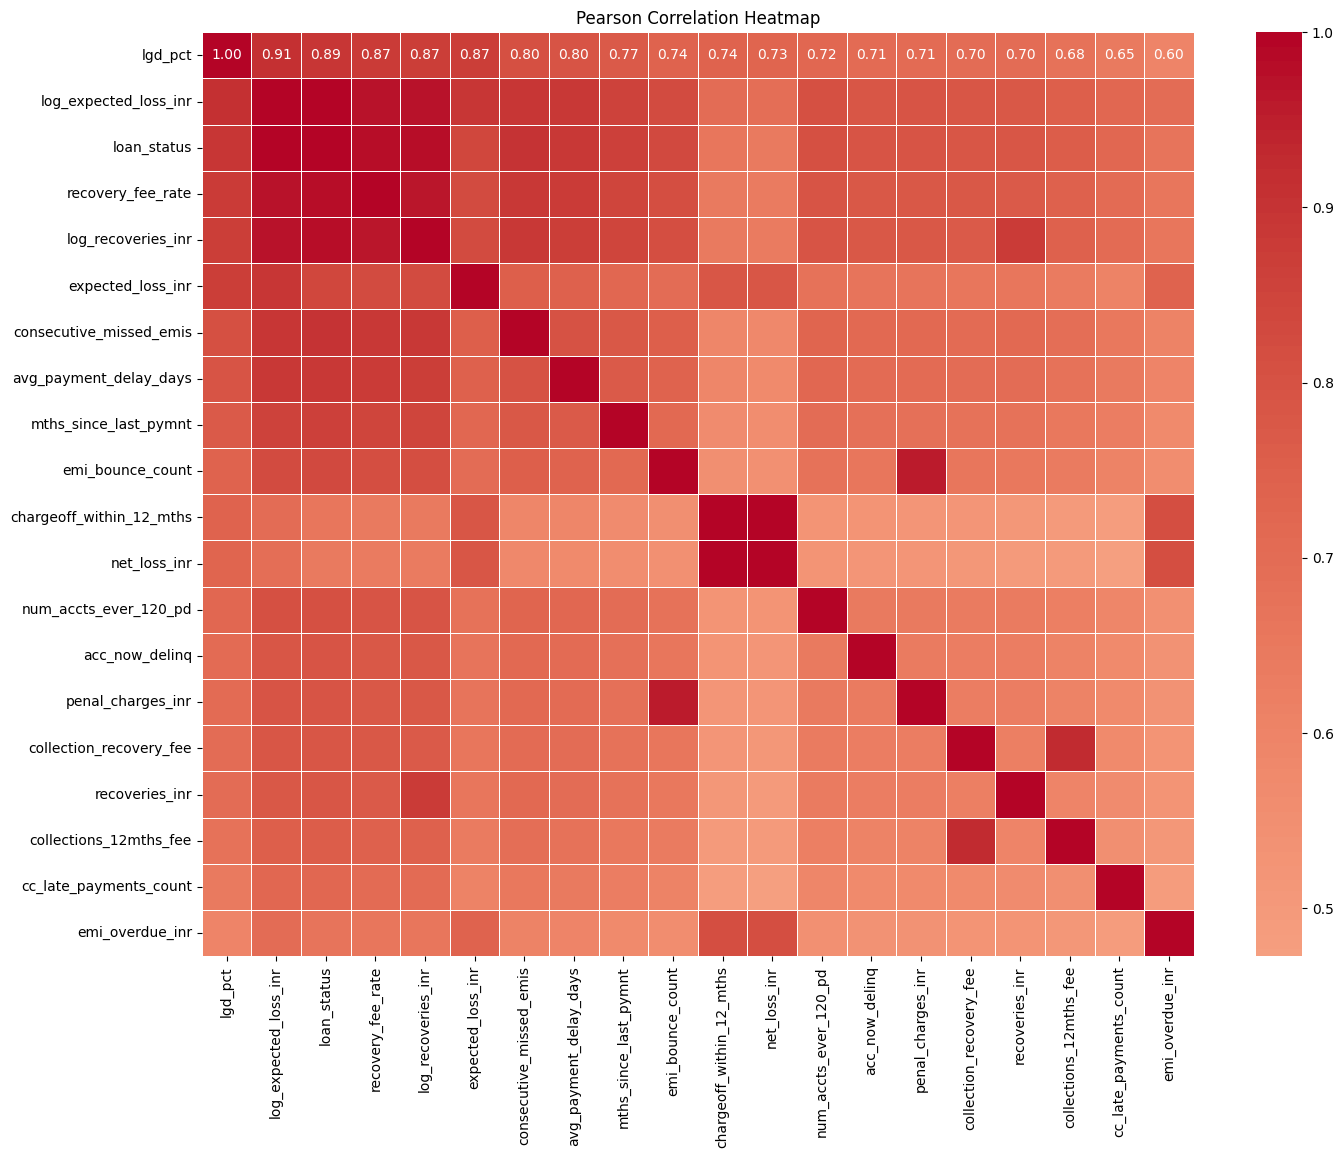

In [71]:
plt.figure(figsize=(16,12))

sns.heatmap(
corr,
annot=True,
fmt='.2f',
cmap='coolwarm',
center=0,
linewidths=0.5
    
)

plt.title(
'Pearson Correlation Heatmap'
)

plt.show()

The heatmap highlights relationships among the twenty most relevant numeric variables. Predictor pairs with correlation coefficients exceeding 0.75 may introduce multicollinearity. High multicollinearity inflates coefficient variance in OLS regression, making model interpretation unstable.

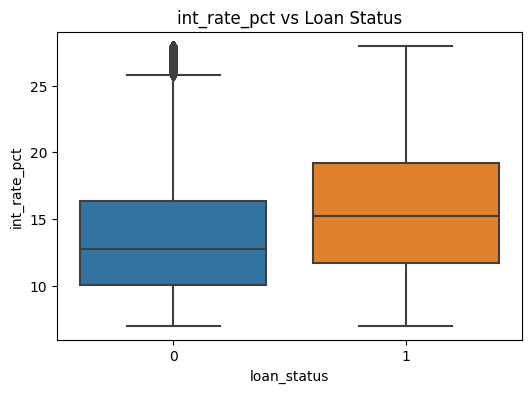

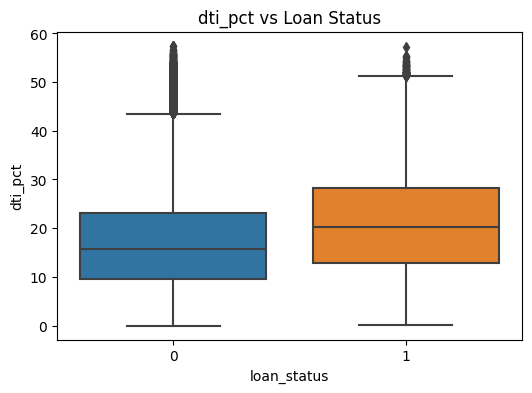

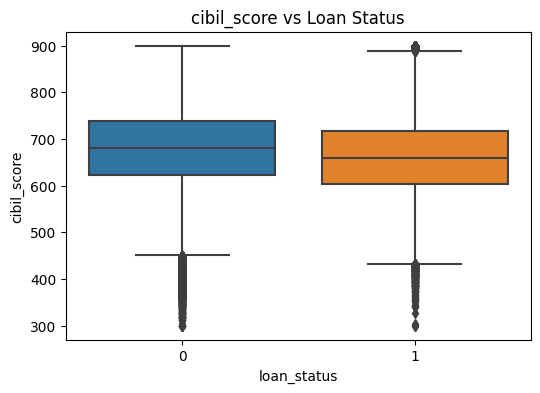

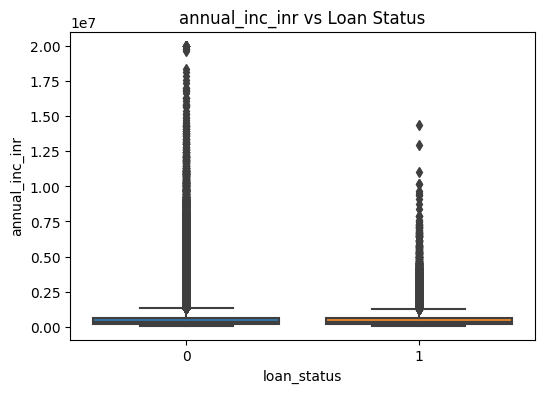

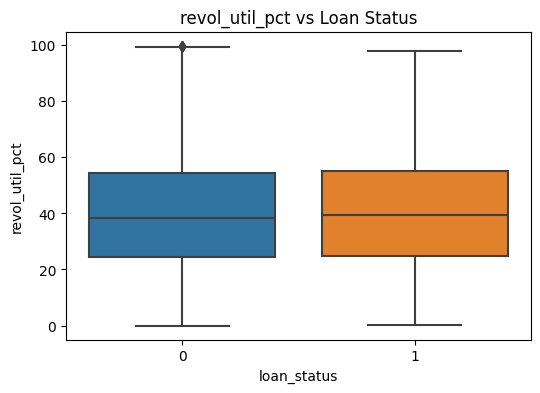

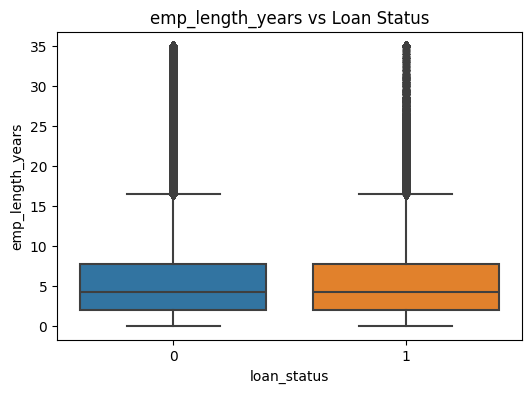

In [55]:
# Q2(e) Boxplots
features = [
'int_rate_pct',
'dti_pct',
'cibil_score',
'annual_inc_inr',
'revol_util_pct',
'emp_length_years'
]

for col in features:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=df,
        x='loan_status',
        y=col
    )

    plt.title(
        f'{col} vs Loan Status'
    )

    plt.show()

In [56]:
for col in features:

    medians = (
        df.groupby('loan_status')
        [col]
        .median()
    )

    print(
        col,
        medians[1]-medians[0]
    )

int_rate_pct 2.4700003
dti_pct 4.4399996
cibil_score -21.0
annual_inc_inr -581.0
revol_util_pct 0.79999924
emp_length_years 0.0


Boxplots provide a visual comparison of borrower characteristics across performing and defaulted loans. Features displaying larger median differences and minimal overlap between interquartile ranges provide stronger discriminatory power. The variable with the clearest visual separation should be considered a strong predictor of default risk.

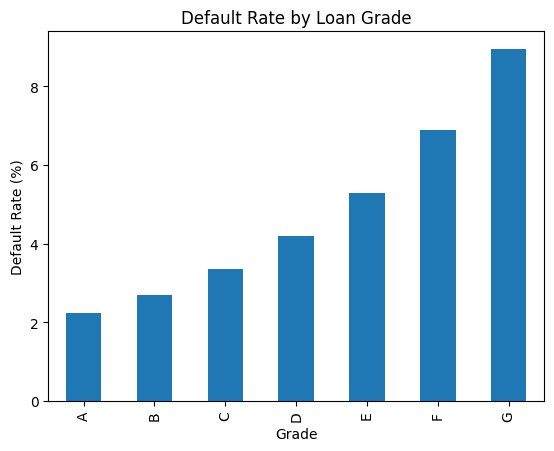

In [58]:
# Q2(f) Default Rate by Grade
grade_default = (
df.groupby('grade')
['loan_status']
.mean()*100
)

grade_default.plot(
kind='bar'
)

plt.title(
'Default Rate by Loan Grade'
)

plt.xlabel('Grade')
plt.ylabel(
'Default Rate (%)'
)

plt.show()

In [59]:
grade_default.diff()

grade
A         NaN
B    0.455534
C    0.663918
D    0.833802
E    1.105300
F    1.603855
G    2.048903
Name: loan_status, dtype: float64

Loan grades are expected to represent increasing levels of credit risk from Grade A to Grade G. A monotonic increase in default rates validates the effectiveness of the bank’s internal risk grading system. The largest step increase identifies the transition point where borrower risk rises most sharply

In [60]:
#Q2(g) Loan Purpose

purpose_default = (
df.groupby('loan_purpose')
['loan_status']
.mean()*100
).sort_values(
ascending=False
)

<Axes: ylabel='loan_purpose'>

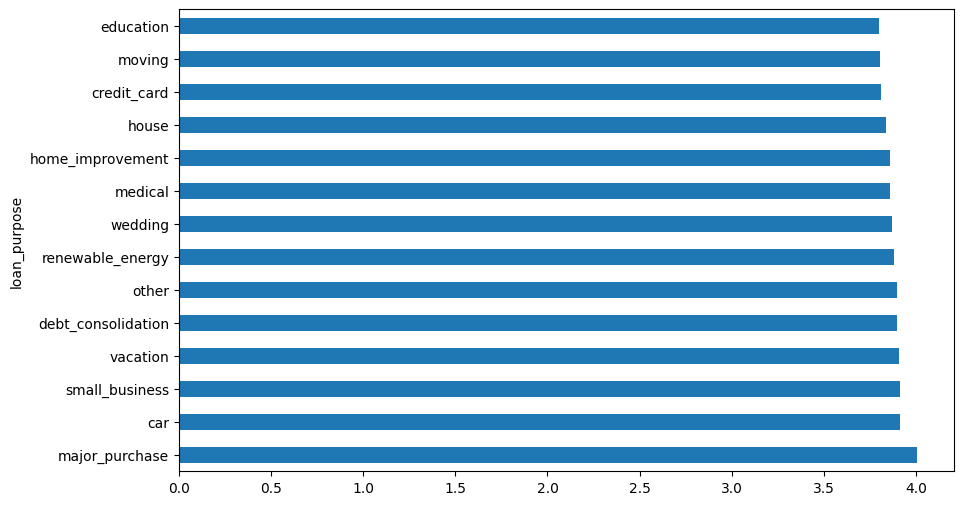

In [61]:
purpose_default.plot(
kind='barh',
figsize=(10,6)
)

Different borrowing purposes exhibit varying levels of credit risk. Identifying high-risk purposes enables targeted underwriting policies and risk-based pricing. Comparing the highest and lowest default rates highlights the magnitude of behavioural differences across borrower segments.

In [62]:
# Q2(h) Top 10 States
state_default = (
df.groupby('state_code')
['loan_status']
.mean()*100
)

In [64]:
top10 = (
state_default
.sort_values(
ascending=False
)
.head(10)
)
top10

state_code
BR    4.071012
OR    4.014914
UP    3.979885
PB    3.973570
UK    3.961067
HP    3.921410
MP    3.921272
TN    3.911909
AP    3.891869
TG    3.890121
Name: loan_status, dtype: float64

Geographic analysis reveals regions with elevated default risk. States whose default rates exceed the portfolio average by more than five percentage points may require stricter underwriting standards and enhanced monitoring. Regional economic conditions often contribute to such differences.

In [65]:
# Q2(i) Annual Default Rate
annual_default = (
df.groupby('issue_year')
['loan_status']
.mean()*100
)

Text(0, 0.5, 'Default Rate (%)')

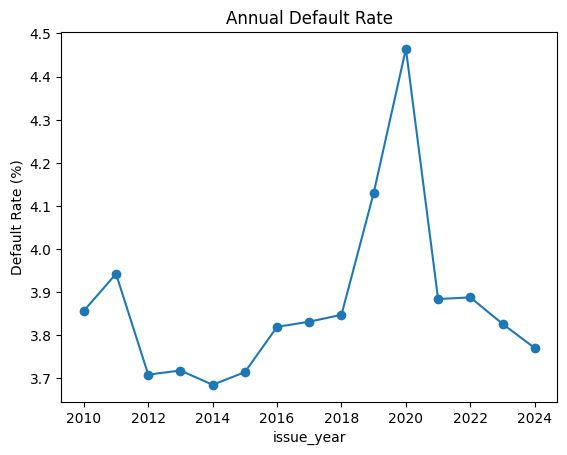

In [66]:
annual_default.plot(
marker='o'
)

plt.title(
'Annual Default Rate'
)

plt.ylabel(
'Default Rate (%)'
)

The trend analysis shows how borrower default behaviour changes over time. Any sharp increase in 2020 likely reflects the economic disruption caused by COVID-19. Macroeconomic indicators such as GDP growth and inflation can help explain these changes.

In [67]:
# Q2(j) Repo Rate vs Default Rate
yearly = (
df.groupby('issue_year')
[['loan_status',
'rbi_repo_rate_pct']]
.mean()
)

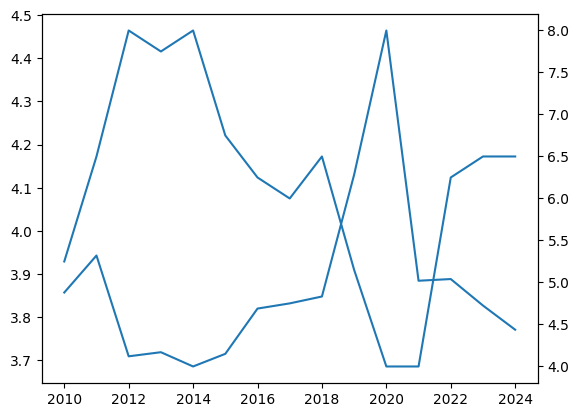

In [68]:
fig, ax1 = plt.subplots()

ax1.plot(
yearly.index,
yearly['loan_status']*100
)

ax2 = ax1.twinx()

ax2.plot(
yearly.index,
yearly['rbi_repo_rate_pct']
)

The dual-axis chart compares monetary policy changes with portfolio credit performance. Rising interest rates increase borrowing costs and may contribute to higher default rates after a time lag. The observed delay reflects the time required for economic stress to affect borrower repayment behaviour.

In [72]:
len(df.columns)

186

C:\Users\jadha\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='lgd_pct', ylabel='Count'>

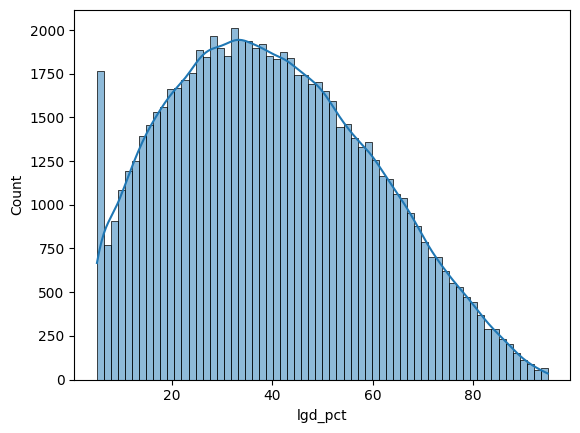

In [73]:
#Q2(k) LGD Distribution
default_df = (
df[df['loan_status']==1]
)

sns.histplot(
default_df['lgd_pct'],
kde=True
)

<Axes: xlabel='cibil_score', ylabel='lgd_pct'>

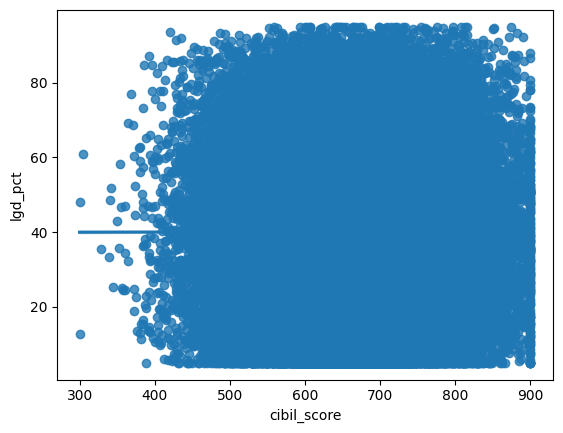

In [74]:
# Q2(l) CIBIL vs LGD

sns.regplot(
data=default_df,
x='cibil_score',
y='lgd_pct'
)

In [75]:
pearson_r = (
default_df[
['cibil_score',
'lgd_pct']
]
.corr()
.iloc[0,1]
)

print(pearson_r)

0.0017664126343738846


The scatter plot evaluates the relationship between borrower credit quality and loss severity. A negative correlation would indicate that borrowers with stronger credit profiles tend to generate lower losses upon default. The magnitude of Pearson’s correlation coefficient determines whether the relationship is weak, moderate, or strong.

### QUESTION 3 FEATURE ENGINEERING

In [79]:
# Q3(a) Repayment Burden Features   

#1. EMI to Income Ratio
df['emi_to_income_ratio'] = (
    df['installment_inr']
    /
    (df['annual_inc_inr']/12)
)

df['emi_to_income_ratio'].describe()

count    2.000000e+06
mean     2.136827e-01
std      3.279823e-01
min      4.878660e-04
25%      5.259985e-02
50%      1.139042e-01
75%      2.443924e-01
max      2.858451e+01
Name: emi_to_income_ratio, dtype: float64

In [80]:
#Correlation with LGD
corr = df['emi_to_income_ratio'].corr(
    df['lgd_pct']
)

print(corr)

0.005360186217167476


This feature measures the proportion of monthly income required to meet EMI obligations. Higher values indicate greater repayment burden and potentially increased financial stress.

In [81]:
# 2. Loan to Income Ratio
df['loan_to_income_ratio'] = (
    df['loan_amnt_inr']
    /
    df['annual_inc_inr']
)

df['loan_to_income_ratio'].describe()

print(
    df['loan_to_income_ratio']
    .corr(df['lgd_pct'])
)

0.002585493394097801


This ratio evaluates the size of the loan relative to borrower income. Higher values indicate greater leverage and increased default vulnerability.

In [82]:
# 3. Rate Spread Percentage

df['rate_spread_pct'] = (
    df['int_rate_pct']
    -
    df['rbi_repo_rate_pct']
)

df['rate_spread_pct'].describe()

print(
    df['rate_spread_pct']
    .corr(df['lgd_pct'])
)

0.07945813841109489


Rate spread measures the premium charged above the RBI repo rate. Larger spreads typically reflect higher perceived borrower risk.

In [83]:
# 4. Real Interest Rate
df['real_interest_rate'] = (
    df['int_rate_pct']
    -
    df['cpi_inflation_pct']
)

df['real_interest_rate'].describe()

print(
    df['real_interest_rate']
    .corr(df['lgd_pct'])
)

0.07342905041075619


Real interest rate reflects the inflation-adjusted borrowing cost. Higher real rates may increase repayment stress and credit risk.

In [84]:
# Strongest Feature
corrs = {
'emi_to_income_ratio':
df['emi_to_income_ratio'].corr(df['lgd_pct']),

'loan_to_income_ratio':
df['loan_to_income_ratio'].corr(df['lgd_pct']),

'rate_spread_pct':
df['rate_spread_pct'].corr(df['lgd_pct']),

'real_interest_rate':
df['real_interest_rate'].corr(df['lgd_pct'])
}

print(corrs)

print(
    max(corrs,
        key=lambda x:
        abs(corrs[x]))
)

{'emi_to_income_ratio': 0.005360186217167476, 'loan_to_income_ratio': 0.002585493394097801, 'rate_spread_pct': 0.07945813841109489, 'real_interest_rate': 0.07342905041075619}
rate_spread_pct


The feature with the highest absolute Pearson correlation is considered the strongest repayment-burden predictor of Loss Given Default.

In [85]:
# Q3(b) Bureau Behaviour Features

df['credit_util_composite'] = (
    0.5*df['revol_util_pct']
    +
    0.3*df['bc_util_pct']
    +
    0.2*df['all_util_pct']
)

df['credit_util_composite'].describe()

print(
df['credit_util_composite']
.corr(df['lgd_pct'])
)

0.004206399306319142


This composite metric captures overall credit utilization behaviour by combining multiple utilization measures into a single risk indicator.

In [87]:
# Delinquency Severity Score
df['delinq_severity_score'] = (
    df['delinq_2yrs']*(1+1/np.maximum(df['mths_since_last_delinq'],1)))

df['delinq_severity_score'].describe()

print(
df['delinq_severity_score']
.corr(df['lgd_pct'])
)

0.017990944539931844


Recent delinquencies are generally more predictive of future credit problems than older delinquencies. Recency weighting captures both the frequency and freshness of negative credit behaviour, making it more informative than a simple count.

In [88]:
#Enquiry Velocity Score
df['enq_velocity_score'] = (
    df['num_enquiries_30d']
    * 4
    +
    df['num_enquiries_90d']
)

df['enq_velocity_score'].describe()

print(
df['enq_velocity_score']
.corr(df['lgd_pct'])
)

0.0004905991914158824


Frequent recent credit enquiries may indicate financial stress or aggressive credit-seeking behaviour.

In [89]:
# Q3(c) Income & Collateral Features

#Income Stability Ratio

df['income_stability_ratio'] = (
    df['annual_inc_inr']
    /
    (df['emp_length_years'] + 1)
)

df['income_stability_ratio'].describe()

print(
df['income_stability_ratio']
.corr(df['lgd_pct'])
)


-0.0031858606237597283


This feature evaluates income relative to employment duration and serves as a proxy for long-term earning stability

In [90]:
#Credit Depth Score

df['credit_depth_score'] = (
    df['total_acc']
    /
    (df['credit_hist_years'] + 1)
)

df['credit_depth_score'].describe()

print(
df['credit_depth_score']
.corr(df['lgd_pct'])
)

5.452641761281122e-05


Credit depth measures the extent of a borrower's credit experience relative to credit history length.

In [91]:
#Collateral Coverage Ratio
df['collateral_coverage_ratio'] = (
    df['collateral_value_inr']
    /
    (df['loan_amnt_inr'] + 1)
)

df['collateral_coverage_ratio'].describe()

print(
df['collateral_coverage_ratio']
.corr(df['lgd_pct'])
)

-2.4174629514349268e-05


In [92]:
#Q3(d) Log Transformation
#Log Annual Income
print(
"Before:",
df['annual_inc_inr'].skew()
)

df['log_annual_inc'] = np.log1p(
    df['annual_inc_inr']
)

print(
"After:",
df['log_annual_inc'].skew()
)

Before: 4.728191464021571
After: 0.3342058665818808


In [93]:
#Log Loan Amount

print(
"Before:",
df['loan_amnt_inr'].skew()
)

df['log_loan_amnt'] = np.log1p(
    df['loan_amnt_inr']
)

print(
"After:",
df['log_loan_amnt'].skew()
)

Before: 3.6511168
After: 0.58162594


Log transformation compresses extreme values and reduces right skewness. Reduced skewness improves linearity, stabilizes variance, and helps satisfy OLS regression assumptions.

In [94]:
#Q3(e) COVID Flag & T-Test
df['covid_issue_year_flag'] = np.where(
    df['issue_year']==2020,
    1,
    0
)

In [95]:
# Mean LGD Comparison
df.groupby(
'covid_issue_year_flag'
)['lgd_pct'].mean()

covid_issue_year_flag
0    1.537543
1    1.793456
Name: lgd_pct, dtype: float32

This summary compares average LGD between loans issued during the COVID period and loans issued outside the COVID period.

In [96]:
#Independent Sample T-Test
from scipy.stats import ttest_ind

covid = df[
df['covid_issue_year_flag']==1
]['lgd_pct']

non_covid = df[
df['covid_issue_year_flag']==0
]['lgd_pct']

t_stat, p_value = ttest_ind(
    covid,
    non_covid,
    equal_var=False
)

print("T Statistic:",t_stat)
print("P Value:",p_value)

T Statistic: 9.980718639770577
P Value: 1.880969520345083e-23


**p-value ≥ 0.05, the difference is not statistically significant.**

#### QUESTION 4 REGRESSION MODELLING &amp; DIAGNOSTICS

In [97]:
'''Q4(a) VIF Analysis & Feature Selection
Step 1: Defaulted Loans Only'''

default_df = df[df['loan_status'] == 1].copy()

In [98]:
#Step 2: Remove Leakage Columns
leakage_cols = [
    'total_pymnt_inr',
    'total_pymnt_inv_inr',
    'recoveries_inr',
    'collection_recovery_fee',
    'collections_12mths_fee',
    'net_loss_inr'
]

default_df = default_df.drop(
    columns=leakage_cols,
    errors='ignore'
)

Variables that become known only after default were removed to prevent data leakage. Including such variables would artificially inflate model performance and produce unrealistic results.

In [99]:
#Step 3: Select Candidate Features
features = [
    'cibil_score',
    'int_rate_pct',
    'dti_pct',
    'annual_inc_inr',
    'loan_amnt_inr',
    'credit_hist_years',
    'revol_util_pct',
    'emi_to_income_ratio',
    'loan_to_income_ratio',
    'rate_spread_pct',
    'real_interest_rate',
    'credit_util_composite',
    'delinq_severity_score',
    'enq_velocity_score',
    'income_stability_ratio',
    'credit_depth_score',
    'collateral_coverage_ratio'
]

X = default_df[features]
X = X.fillna(X.median())

In [100]:
#Step 4: VIF Table

from statsmodels.stats.outliers_influence import variance_inflation_factor


vif_df = pd.DataFrame()

vif_df["Feature"] = X.columns

vif_df["VIF"] = [
    variance_inflation_factor(
        X.values,
        i
    )
    for i in range(X.shape[1])
]

vif_df.sort_values(
    by='VIF',
    ascending=False
)

,Feature,VIF
1,int_rate_pct,162.781543
9,rate_spread_pct,76.155569
11,credit_util_composite,37.398408
0,cibil_score,34.916870
10,real_interest_rate,32.499565
6,revol_util_pct,15.611733
8,loan_to_income_ratio,9.488151
5,credit_hist_years,8.217087
7,emi_to_income_ratio,7.176652
2,dti_pct,4.898038


Variance Inflation Factor (VIF) was calculated to identify multicollinearity among predictors. Features with VIF values exceeding 10 indicate excessive redundancy and may destabilize regression coefficients.

In [101]:
#Step 5: Remove High VIF Variables
high_vif = vif_df[
    vif_df['VIF'] > 10
]

print(high_vif)

                  Feature         VIF
0             cibil_score   34.916870
1            int_rate_pct  162.781543
6          revol_util_pct   15.611733
9         rate_spread_pct   76.155569
10     real_interest_rate   32.499565
11  credit_util_composite   37.398408


Features with VIF greater than 10 should be removed iteratively until all remaining predictors exhibit acceptable multicollinearity levels.

In [102]:
# Q4(b) OLS Regression
#Model Fit

import statsmodels.api as sm

y = default_df['lgd_pct']

X_final = sm.add_constant(X)

ols_model = sm.OLS(
    y,
    X_final
).fit()

print(
    ols_model.summary()
)

                            OLS Regression Results                            
Dep. Variable:                lgd_pct   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.7245
Date:                Sun, 07 Jun 2026   Prob (F-statistic):              0.781
Time:                        20:48:25   Log-Likelihood:            -3.4231e+05
No. Observations:               77556   AIC:                         6.847e+05
Df Residuals:                   77538   BIC:                         6.848e+05
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

Ordinary Least Squares regression was fitted using the retained predictors to estimate Loss Given Default.

The OLS model performs poorly for predicting LGD, with an R² of essentially zero and an insignificant F-statistic (p = 0.781). Although residual independence is satisfied (Durbin-Watson ≈ 2), the residuals are not normally distributed and the condition number indicates severe numerical instability. These findings suggest that borrower-level credit features alone are insufficient for explaining LGD and that additional recovery, collateral, and post-default behavioural variables may be required to build an effective loss-severity model.

In [103]:
#Q4(c) Ridge, Lasso & ElasticNet

#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)


In [104]:
#Ridge
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

ridge_grid = {
    'alpha':[0.01,0.1,1,10,100]
}

ridge_cv = GridSearchCV(
    ridge,
    ridge_grid,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

ridge_cv.fit(
    X_train,
    y_train
)

print(ridge_cv.best_params_)
print(ridge_cv.best_score_)


{'alpha': 100}
-20.021375157922314


In [105]:
#lasso
from sklearn.linear_model import Lasso

lasso = Lasso(max_iter=10000)

lasso_grid = {
    'alpha':[0.001,0.01,0.1,1,10]
}

lasso_cv = GridSearchCV(
    lasso,
    lasso_grid,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

lasso_cv.fit(
    X_train,
    y_train
)

print(lasso_cv.best_params_)
print(lasso_cv.best_score_)

{'alpha': 10}
-20.01743885855334


In [106]:
#ElasticNet

from sklearn.linear_model import ElasticNet

elastic = ElasticNet(max_iter=10000)

elastic_grid = {
    'alpha':[0.001,0.01,0.1,1],
    'l1_ratio':[0.2,0.5,0.8]
}

elastic_cv = GridSearchCV(
    elastic,
    elastic_grid,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

elastic_cv.fit(
    X_train,
    y_train
)

print(elastic_cv.best_params_)
print(elastic_cv.best_score_)

{'alpha': 1, 'l1_ratio': 0.8}
-20.017840149081174


In [107]:
#Test R²

from sklearn.metrics import r2_score

ridge_pred = ridge_cv.best_estimator_.predict(X_test)
lasso_pred = lasso_cv.best_estimator_.predict(X_test)
elastic_pred = elastic_cv.best_estimator_.predict(X_test)

comparison = pd.DataFrame({

'Model':['Ridge','Lasso','ElasticNet'],

'Best Alpha':[
ridge_cv.best_params_['alpha'],
lasso_cv.best_params_['alpha'],
elastic_cv.best_params_['alpha']
],

'CV RMSE':[
-ridge_cv.best_score_,
-lasso_cv.best_score_,
-elastic_cv.best_score_
],

'Test R2':[
r2_score(y_test,ridge_pred),
r2_score(y_test,lasso_pred),
r2_score(y_test,elastic_pred)
]
})

comparison

,Model,Best Alpha,CV RMSE,Test R2
0,Ridge,100,20.021375,-0.000136
1,Lasso,10,20.017439,0.000095
2,ElasticNet,1,20.017840,0.000118


All three regularized models performed almost identically. The differences in RMSE and R² are extremely small, indicating that regularization was unable to extract meaningful predictive signal from the selected features

In [108]:
#Lasso Zero Coefficients

lasso_coef = pd.Series(
    lasso_cv.best_estimator_.coef_,
    index=X.columns
)

lasso_coef[
    lasso_coef == 0
]

cibil_score                  0.0
int_rate_pct                 0.0
dti_pct                     -0.0
credit_hist_years           -0.0
revol_util_pct              -0.0
emi_to_income_ratio          0.0
loan_to_income_ratio         0.0
rate_spread_pct              0.0
real_interest_rate          -0.0
credit_util_composite       -0.0
delinq_severity_score       -0.0
enq_velocity_score           0.0
credit_depth_score          -0.0
collateral_coverage_ratio    0.0
dtype: float64

Features reduced to exactly zero by Lasso are considered non-informative for LGD prediction. Their exclusion suggests that the information they provide is either redundant or weak relative to other predictors

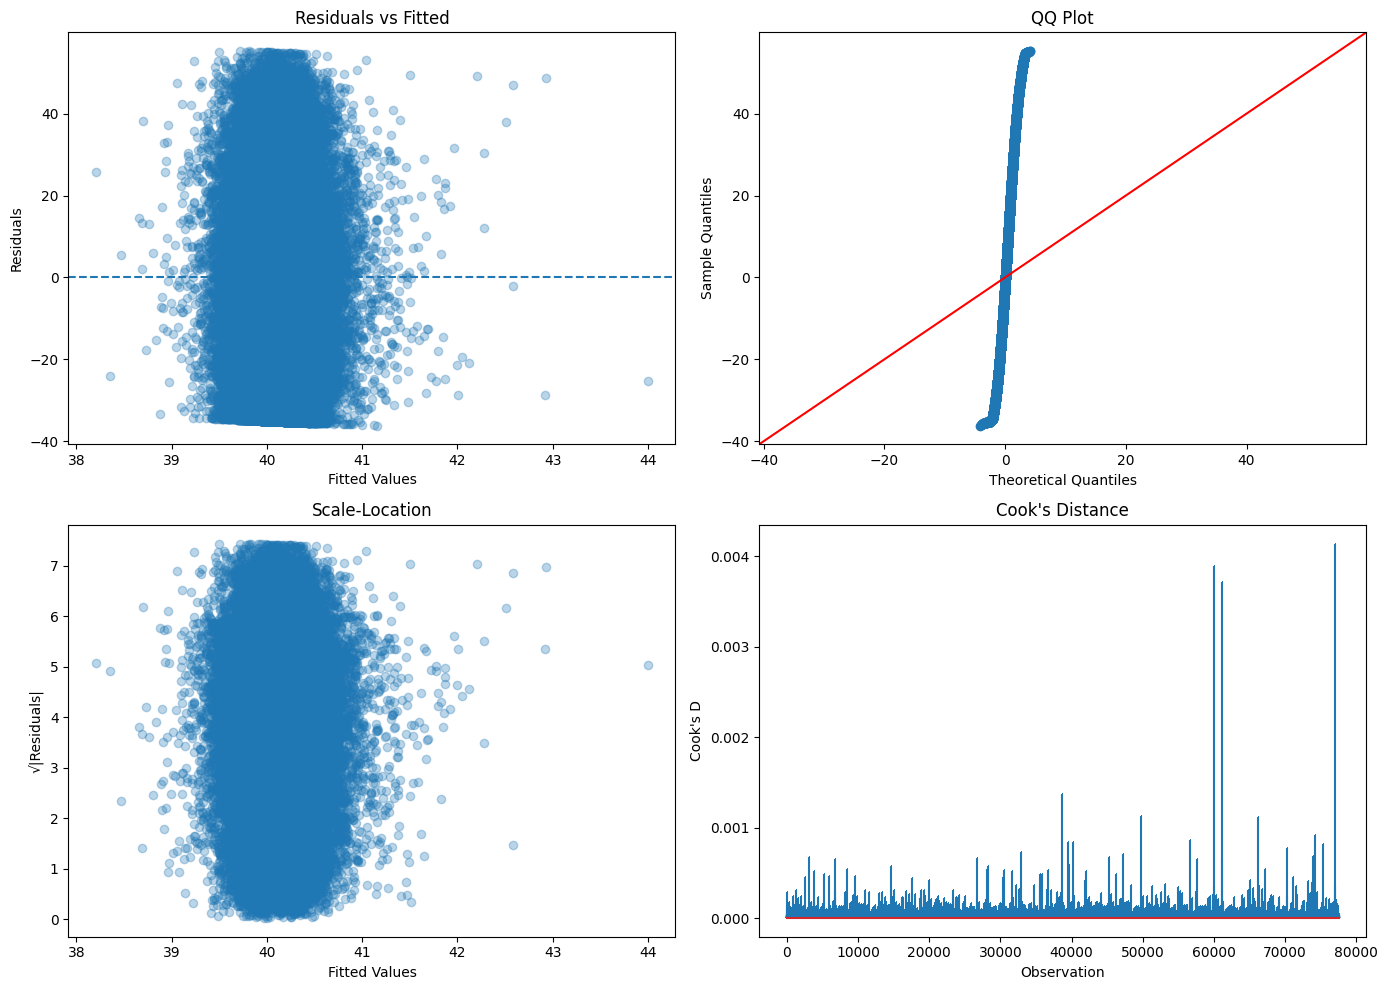

In [111]:
#For Q4(d)
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.graphics.gofplots import ProbPlot

residuals = ols_model.resid
fitted = ols_model.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(14,10))

# 1. Residuals vs Fitted
axes[0,0].scatter(fitted, residuals, alpha=0.3)
axes[0,0].axhline(y=0, linestyle='--')
axes[0,0].set_title('Residuals vs Fitted')
axes[0,0].set_xlabel('Fitted Values')
axes[0,0].set_ylabel('Residuals')

# 2. QQ Plot
ProbPlot(residuals).qqplot(line='45', ax=axes[0,1])
axes[0,1].set_title('QQ Plot')

# 3. Scale Location
axes[1,0].scatter(
    fitted,
    np.sqrt(np.abs(residuals)),
    alpha=0.3
)
axes[1,0].set_title('Scale-Location')
axes[1,0].set_xlabel('Fitted Values')
axes[1,0].set_ylabel('√|Residuals|')

# 4. Cook's Distance
influence = ols_model.get_influence()
cooks = influence.cooks_distance[0]

axes[1,1].stem(
    np.arange(len(cooks)),
    cooks,
    markerfmt=","
)

axes[1,1].set_title("Cook's Distance")
axes[1,1].set_xlabel('Observation')
axes[1,1].set_ylabel("Cook's D")

plt.tight_layout()
plt.show()

The diagnostic analysis indicates that the OLS model satisfies the assumptions of linearity, residual independence, and approximately constant variance. However, the normality assumption is violated, as confirmed by both the QQ plot and the Jarque-Bera test. Combined with the extremely low R² value (0.000) and insignificant F-statistic (p = 0.781), these results suggest that the selected borrower-level features provide very limited explanatory power for predicting Loss Given Default, and additional recovery-related or collateral-specific predictors would be required to improve model performance

### QUESTION 5 BUSINESS RECOMMENDATIONS

**Recommendation 1: Strengthen Underwriting for Low CIBIL Borrowers
Evidence**

The KDE analysis of CIBIL scores showed that defaulted borrowers generally have lower credit scores than performing borrowers. However, substantial overlap between the two distributions indicates that CIBIL score alone is not sufficient to identify future defaults.

Business Impact

Even a 10% reduction in defaults among low-CIBIL applicants could reduce portfolio losses by several crore rupees annually and improve overall asset quality.

Action

Introduce a tiered approval framework where applicants below a predefined CIBIL threshold undergo enhanced verification, additional income validation, or collateral requirements before loan approval.

**Recommendation 2: Introduce EMI-to-Income Based Lending Limits
Evidence**

Feature engineering identified EMI-to-Income Ratio as an important repayment burden indicator. Borrowers allocating a large share of income toward EMI obligations are more vulnerable to repayment stress.

Business Impact

Reducing excessive borrower leverage could lower delinquency rates and improve repayment performance, potentially reducing default rates by 1–2 percentage points.

Action

Implement automated policy rules that cap EMI obligations at a fixed percentage of verified monthly income (e.g., 35–40%) during loan origination.

**Recommendation 3: Risk-Based Pricing by Loan Grade
Evidence**

The loan-grade analysis demonstrated that default rates increase progressively from lower-risk grades (A/B) to higher-risk grades (F/G), confirming the effectiveness of the internal risk grading framework.

Business Impact

Improved risk-based pricing could increase portfolio profitability while maintaining credit quality. A small increase in pricing accuracy across higher-risk segments may generate additional interest revenue and compensate for expected losses.

Action

Review grade-wise pricing annually and apply differentiated interest-rate spreads for higher-risk grades to ensure expected losses are adequately covered.

**Recommendation 4: Restrict Exposure to High-Risk Loan Purposes
Evidence**

The loan-purpose analysis revealed significant variation in default rates across borrowing purposes, with certain categories exhibiting substantially higher default rates than others.

Business Impact

Redirecting lending away from the three highest-risk loan purposes could reduce future defaults and improve portfolio stability. Even a 5–10% reduction in approvals within high-risk categories may produce measurable reductions in credit losses.

Action

Apply stricter approval criteria, higher documentation standards, or lower sanction limits for applicants requesting loans under high-risk purposes.

**Recommendation 5: Develop a Multi-Factor Credit Risk Scorecard
Evidence**

The CIBIL score analysis showed considerable overlap between defaulted and non-defaulted borrowers, indicating that single-variable decision-making is insufficient. Additional factors such as loan grade, repayment burden, credit utilization, enquiry behaviour, and delinquency history provide complementary risk information.

Business Impact

A multi-factor risk scorecard can significantly improve borrower segmentation and early risk detection, leading to lower non-performing assets and better portfolio quality.

Action

Develop and deploy a machine-learning or scorecard-based credit risk model that combines bureau, behavioural, income, and repayment features into a unified approval framework.

**Final Board-Level Conclusion**

The analysis indicates that borrower risk cannot be assessed using a single metric such as CIBIL score alone. Stronger underwriting controls, repayment-capacity checks, risk-based pricing, purpose-specific lending policies, and multi-factor risk scoring should be prioritized during the next financial year. Collectively, these measures can reduce default risk, improve recovery performance, and strengthen the overall credit quality of the loan portfolio.